# Hometask

1. Load the Electricity Consumption data in Romania (```./datasets/electricity_consumption_and_production.csv```). Use the Consumption column as the target variable.
2. Perform EDA: decompose the series, plot ACF and PACF, and run the ADF stationarity test. Note that the data contains hourly observations — resample to daily before performing forecast.
3. Clean data if necessary.
4. Train forecasting models (Use models from the lecture or other ones if you wish) and produce forecasts for 15, 30, and 45 days ahead.
5. Visualize predictions and provide evaluation metrics


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal  import seasonal_decompose
import warnings
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns
warnings.filterwarnings('ignore')

# Load dataset

In [29]:
df = pd.read_csv('data/electricity_consumption_and_production.csv', parse_dates=['DateTime'], index_col='DateTime')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (54161, 9)


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [30]:
con = df['Consumption'].copy()
con_df = con.to_frame(name="Consumption")

con_daily = con_df.resample("D").mean()
con_daily.head()

,Consumption
DateTime,
2019-01-01,5924.478261
2019-01-02,6322.041667
2019-01-03,7254.083333
2019-01-04,7635.083333
2019-01-05,7423.521739


In [31]:
print(f'NaN: {con_daily.isna().sum()}')
print(f'Duplicates: {con_daily.index.duplicated().sum()}')

NaN: Consumption    2
dtype: int64
Duplicates: 0


In [32]:
con_daily['Consumption'] = con_daily['Consumption'].interpolate(method='linear')
print(f'NaN: {con_daily.isna().sum()}')

NaN: Consumption    0
dtype: int64


<Figure size 1600x600 with 0 Axes>

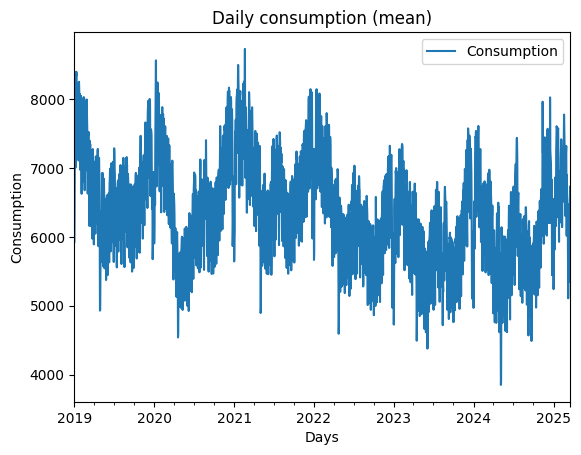

In [33]:
plt.figure(figsize=(16,6))
con_daily.plot()

plt.title('Daily consumption (mean)')
plt.xlabel('Days')
plt.ylabel('Consumption')
plt.show()

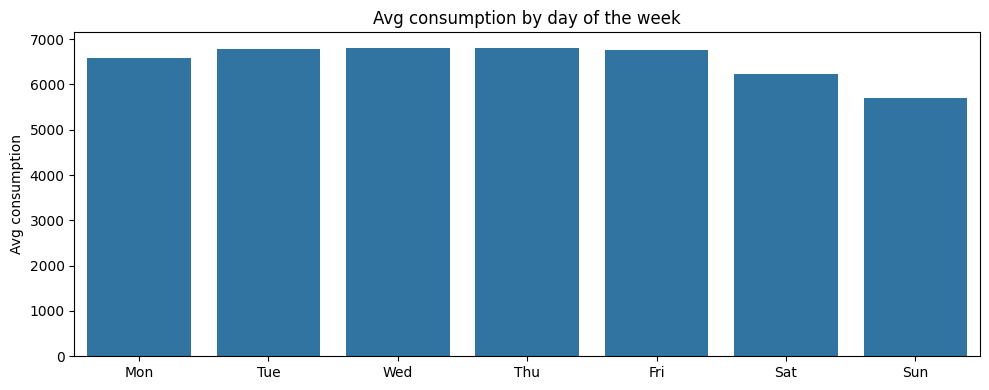

In [34]:
df["Weekday"] = df.index.weekday
weekday_avg = df.groupby("Weekday")["Consumption"].mean()

plt.figure(figsize=(10, 4))
sns.barplot(x=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], y=weekday_avg.values)
plt.title("Avg consumption by day of the week")
plt.ylabel("Avg consumption")
plt.tight_layout()
plt.show()

# EDA

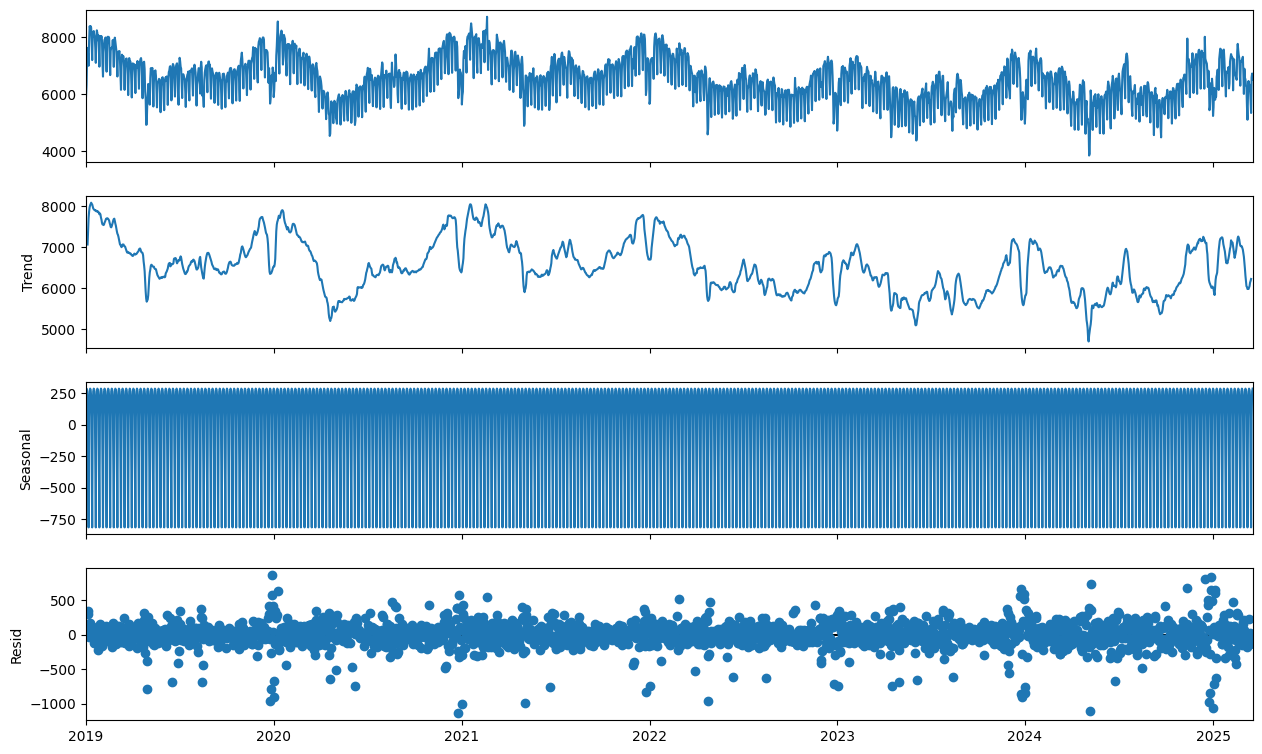

In [35]:
decomp = seasonal_decompose(con_daily, model='additive', period=7)

fig = decomp.plot()
fig.set_size_inches(14,8)

# ACF and PACF

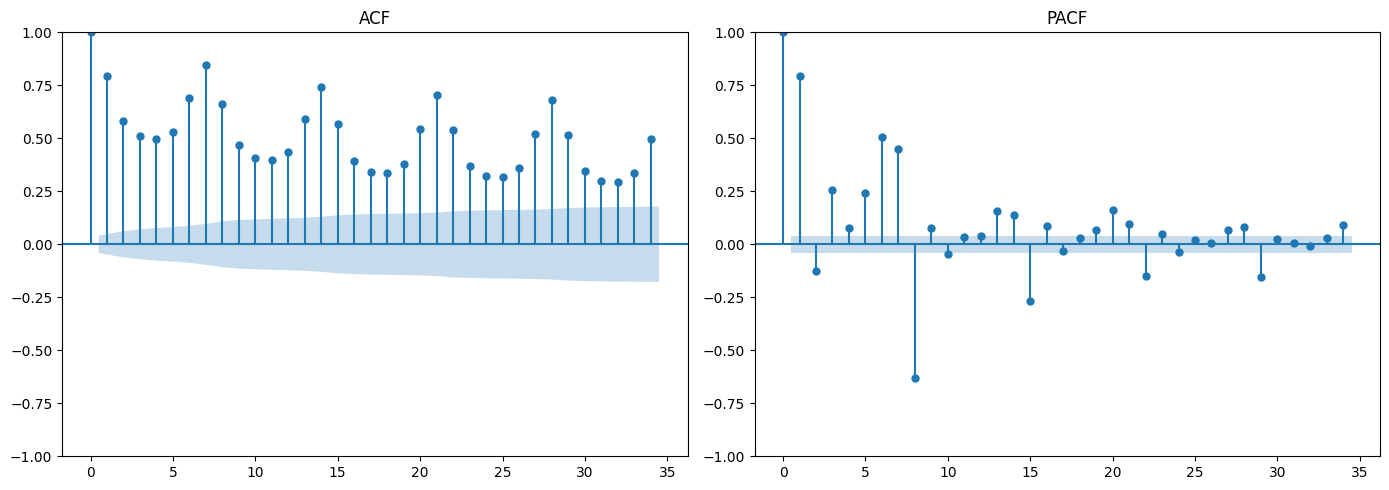

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(con_daily, title="ACF", ax=ax[0])
plot_pacf(con_daily, title="PACF", ax=ax[1])

plt.tight_layout()

# ADF stationarity test

In [37]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(con_daily)
p_value = result[1]

adf_output = pd.Series({
    'Test Statistic': result[0],
    'p-value': result[1],
    'Lags Used': result[2],
    'Observations Used': result[3]
})

adf_output

Test Statistic         -3.388398
p-value                 0.011361
Lags Used              27.000000
Observations Used    2242.000000
dtype: float64

# Train forecasting models and produce forecasts for 15, 30, and 45 days ahead

In [38]:
def evaluate_forecast(actual, forecast):    
    actual_vals = actual.values().flatten()
    forecast_vals = forecast.values().flatten()
    
    min_len = min(len(actual_vals), len(forecast_vals))
    actual_vals = actual_vals[:min_len]
    forecast_vals = forecast_vals[:min_len]
    
    mask = ~(np.isnan(actual_vals) | np.isnan(forecast_vals))
    actual_vals = actual_vals[mask]
    forecast_vals = forecast_vals[mask]
    
    if len(actual_vals) == 0:
        return 0.0
    
    mape = mean_absolute_percentage_error(actual_vals, forecast_vals)
    
    return round(mape * 100, 2)


def plot_forecasts(steps, forecasts_dict, model_name):

    _, axes = plt.subplots(3, 1, figsize=(15, 10))
    
    for ind, (step, (train, test)) in enumerate(steps.items()):
        ax = axes[ind]
        
        train_last_90 = train[-90:]
        train_last_90.plot(ax=ax, label='Train (last 90 days)', color='blue', linewidth=2)
        
        test.plot(ax=ax, label='Actual', color='green', linewidth=2)
        
        forecast = forecasts_dict[step]
        forecast.plot(ax=ax, label=f'{model_name} Forecast', color='red', linewidth=2)
        
        mape = evaluate_forecast(test, forecast)
        
        ax.set_title(f'{model_name}: {step}-Day Forecast (MAPE: {mape}%)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel('Consumption', fontsize=11)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [39]:
from darts import TimeSeries

con_daily_ts = TimeSeries.from_dataframe(
    con_daily,
    value_cols="Consumption",
    freq="D"
)

In [40]:
train_15, test_15 = con_daily_ts[:-15], con_daily_ts[-15:]
train_30, test_30 = con_daily_ts[:-30], con_daily_ts[-30:]
train_45, test_45 = con_daily_ts[:-45], con_daily_ts[-45:]

steps = {15: (train_15, test_15), 30: (train_30, test_30), 45: (train_45, test_45)}


# SARIMA

In [41]:
from darts.models import ARIMA

sarima_forecasts = {}

for step, (train, test) in steps.items():
    print(f"Training SARIMA for {step}-day forecast")
    
    model = ARIMA(1, 1, 1, (1, 1, 1, 7))
    model.fit(train)
    
    forecast = model.predict(step)
    sarima_forecasts[step] = forecast

print("\nTraining of all SARIMA models completed successfully")

Training SARIMA for 15-day forecast
Training SARIMA for 30-day forecast
Training SARIMA for 45-day forecast

Training of all SARIMA models completed successfully


# SARIMA visualization and evaluation

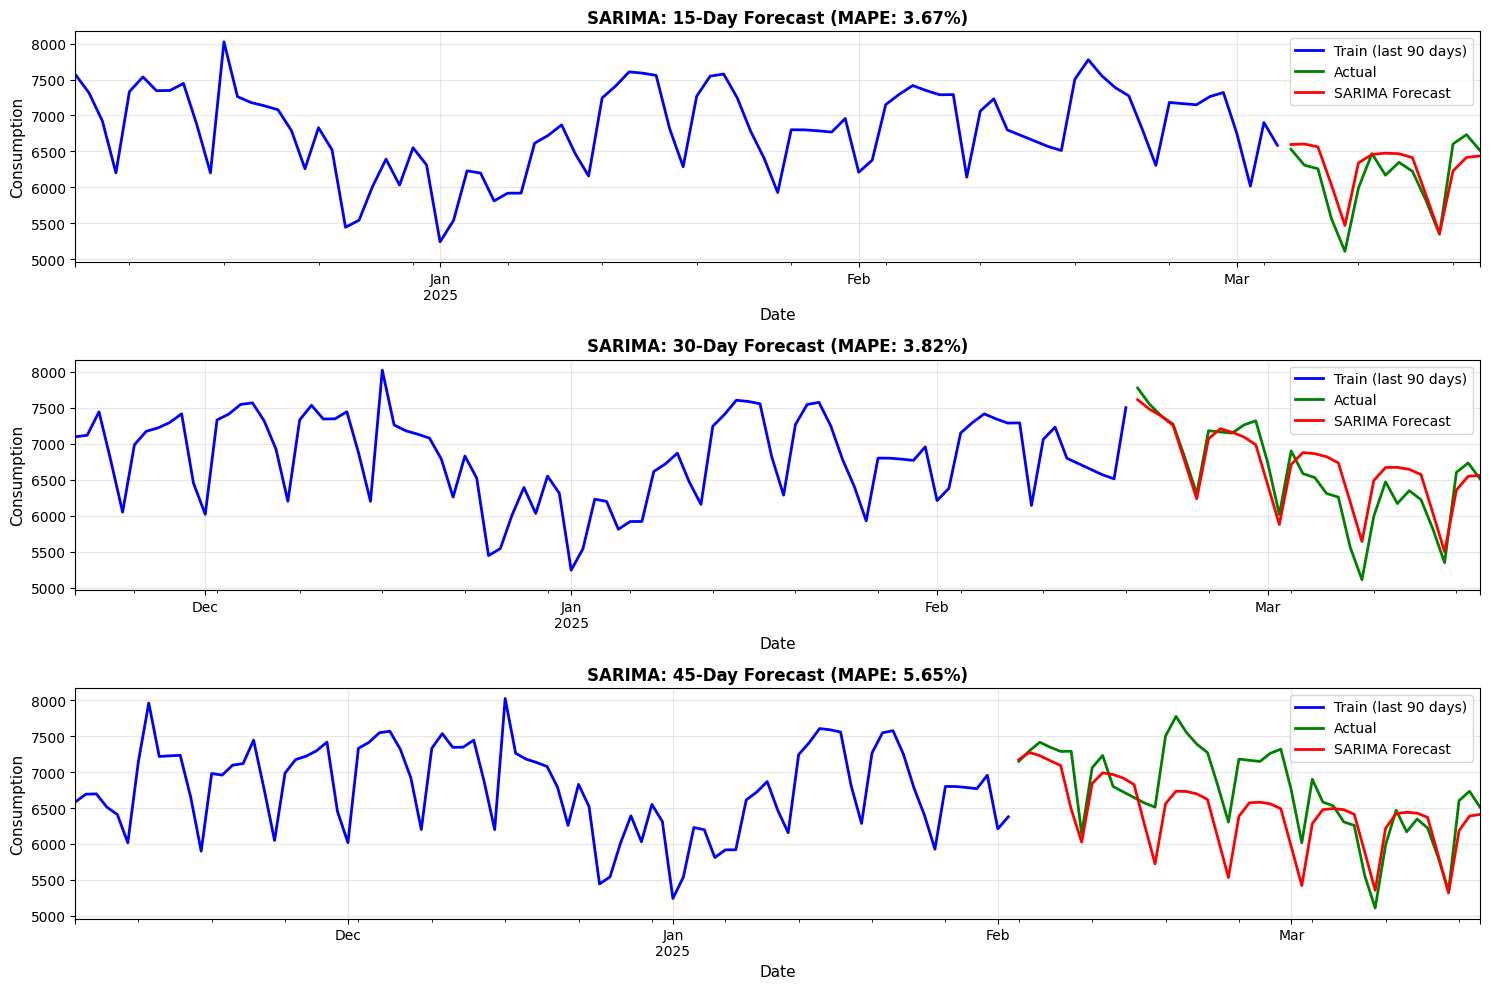

In [42]:
plot_forecasts(steps, sarima_forecasts, 'SARIMA')

# Exponential Smoothing

In [43]:
from darts.models import ExponentialSmoothing

es_forecasts = {}

for step, (train, test) in steps.items():
    print(f"Training ES for {step}-day forecast")
    
    model = ExponentialSmoothing(seasonal_periods=7)
    model.fit(train)
    
    forecast = model.predict(step)
    es_forecasts[step] = forecast

print("\nTraining of all ES models completed successfully")

Training ES for 15-day forecast
Training ES for 30-day forecast
Training ES for 45-day forecast

Training of all ES models completed successfully


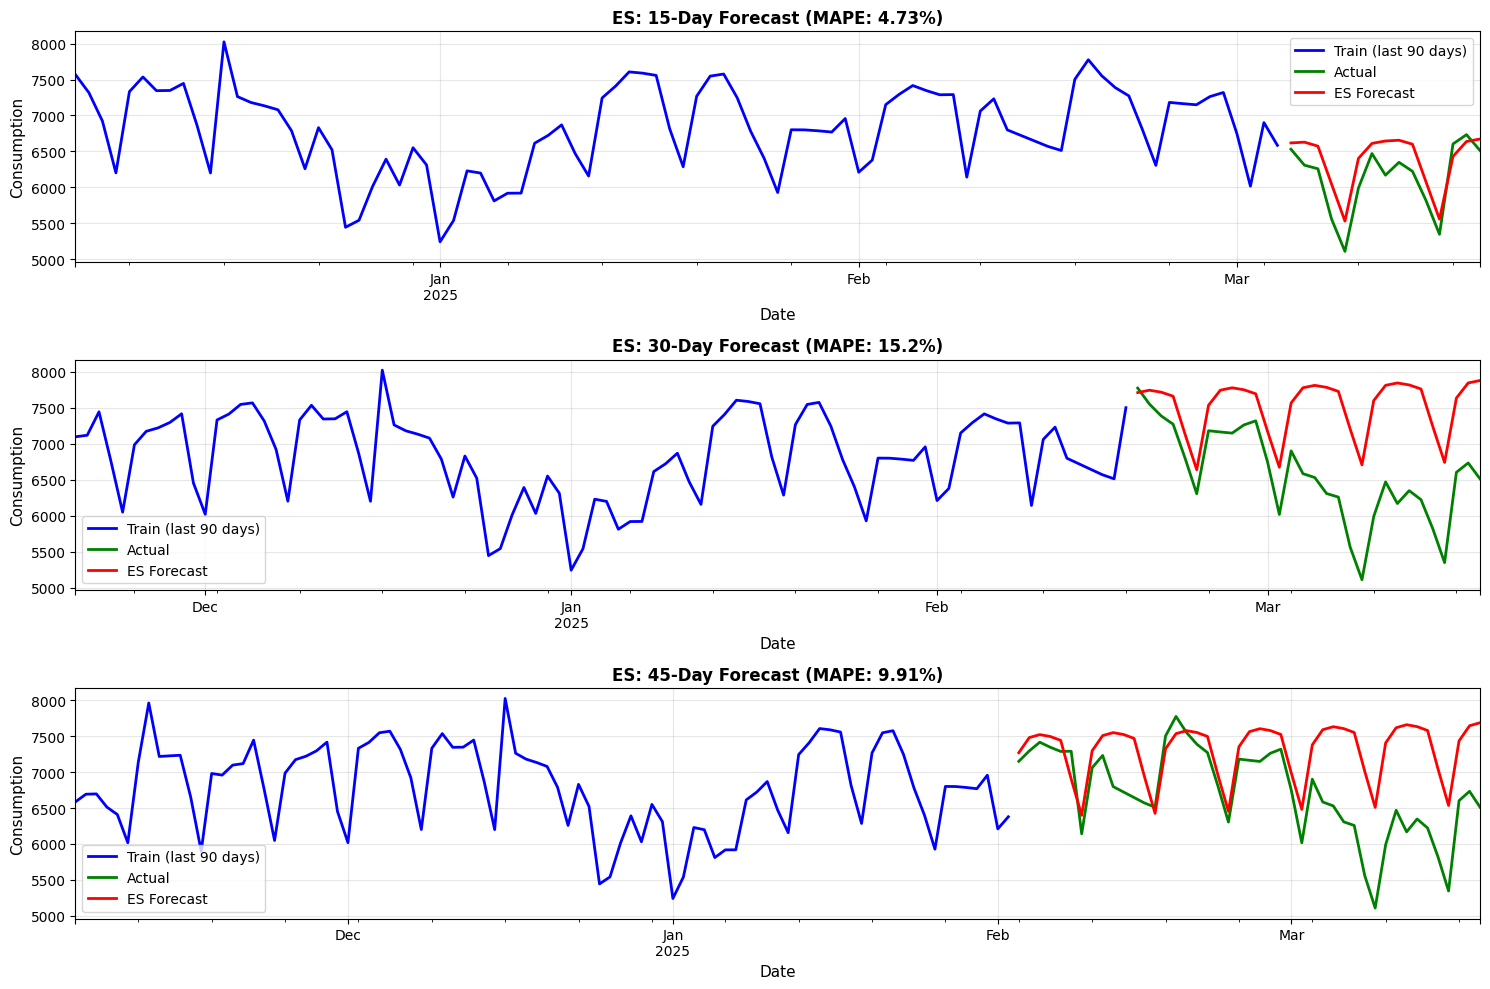

In [44]:
plot_forecasts(steps, es_forecasts, 'ES')

# Prophet

In [45]:
from darts.models import Prophet

prophet_forecasts = {}

for step, (train, test) in steps.items():
    print(f"Training Prophet for {step}-day forecast")
    
    model = Prophet()
    model.fit(train)
    
    forecast = model.predict(step)
    prophet_forecasts[step] = forecast

print("\nTraining of all Prophet models completed successfully")

18:47:07 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for 15-day forecast


18:47:08 - cmdstanpy - INFO - Chain [1] done processing
18:47:08 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for 30-day forecast


18:47:08 - cmdstanpy - INFO - Chain [1] done processing
18:47:08 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for 45-day forecast


18:47:08 - cmdstanpy - INFO - Chain [1] done processing



Training of all Prophet models completed successfully


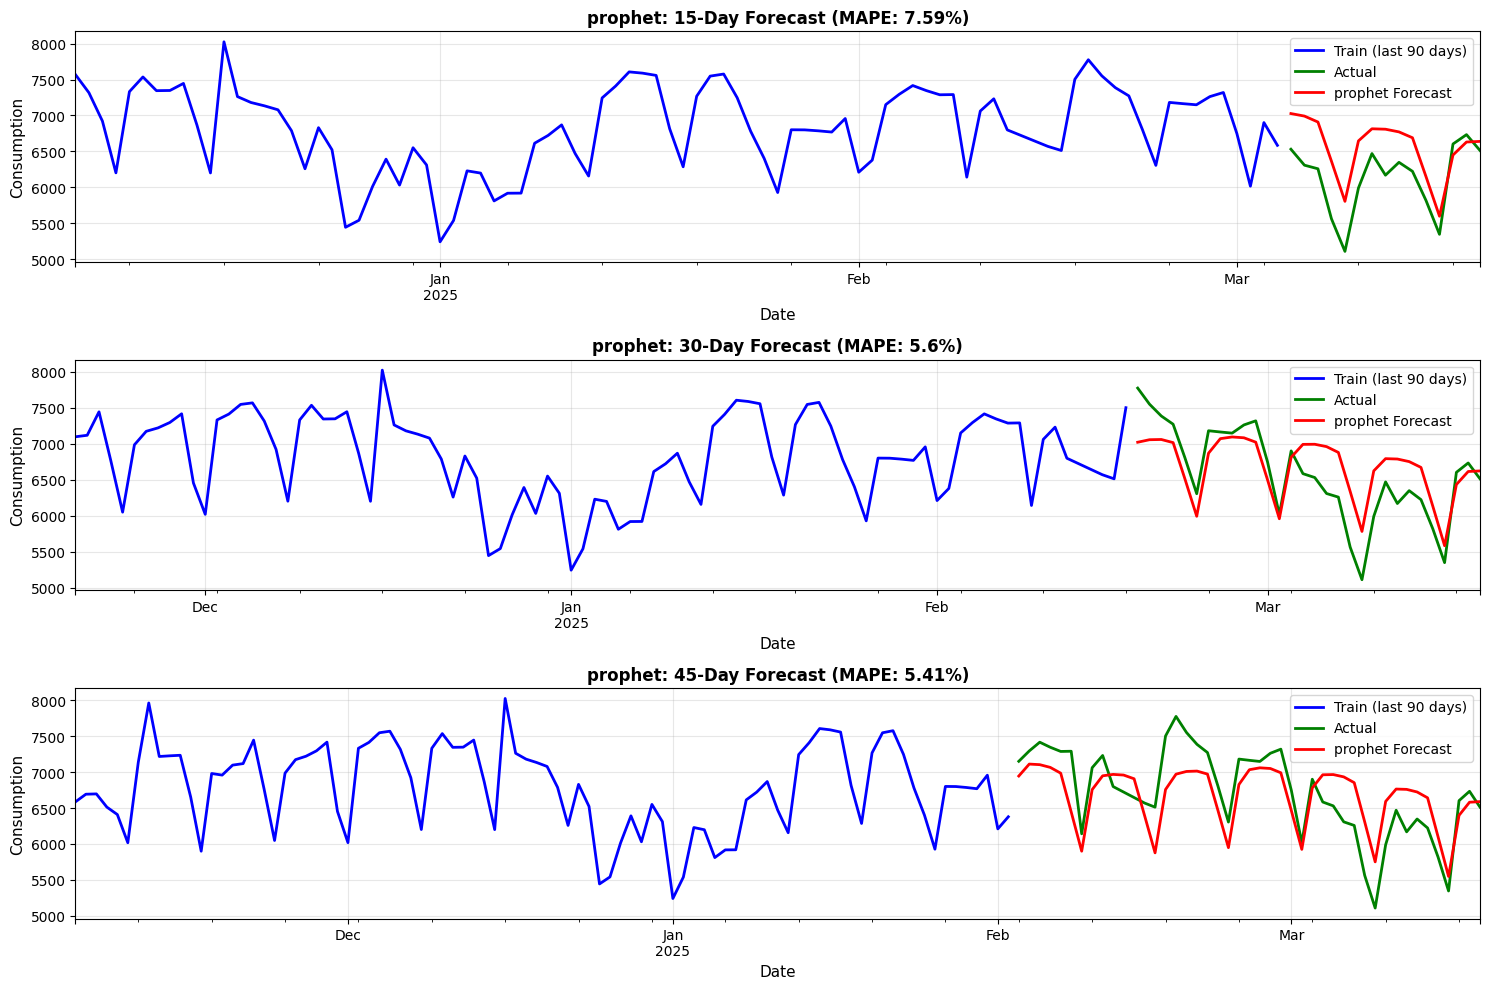

In [46]:
plot_forecasts(steps, prophet_forecasts, 'prophet')

# XGBoost

In [47]:
from darts.models import XGBModel

xgb_forecasts = {}

for step, (train, test) in steps.items():
    print(f"Training XGBoost for {step}-day forecast")
    
    model = XGBModel(
        lags=28,
        n_estimators=200,
        max_depth=7,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(train)
    
    forecast = model.predict(step)
    xgb_forecasts[step] = forecast

print("\nTraining of all XGBoost models completed successfully")

Training XGBoost for 15-day forecast
Training XGBoost for 30-day forecast
Training XGBoost for 45-day forecast

Training of all XGBoost models completed successfully


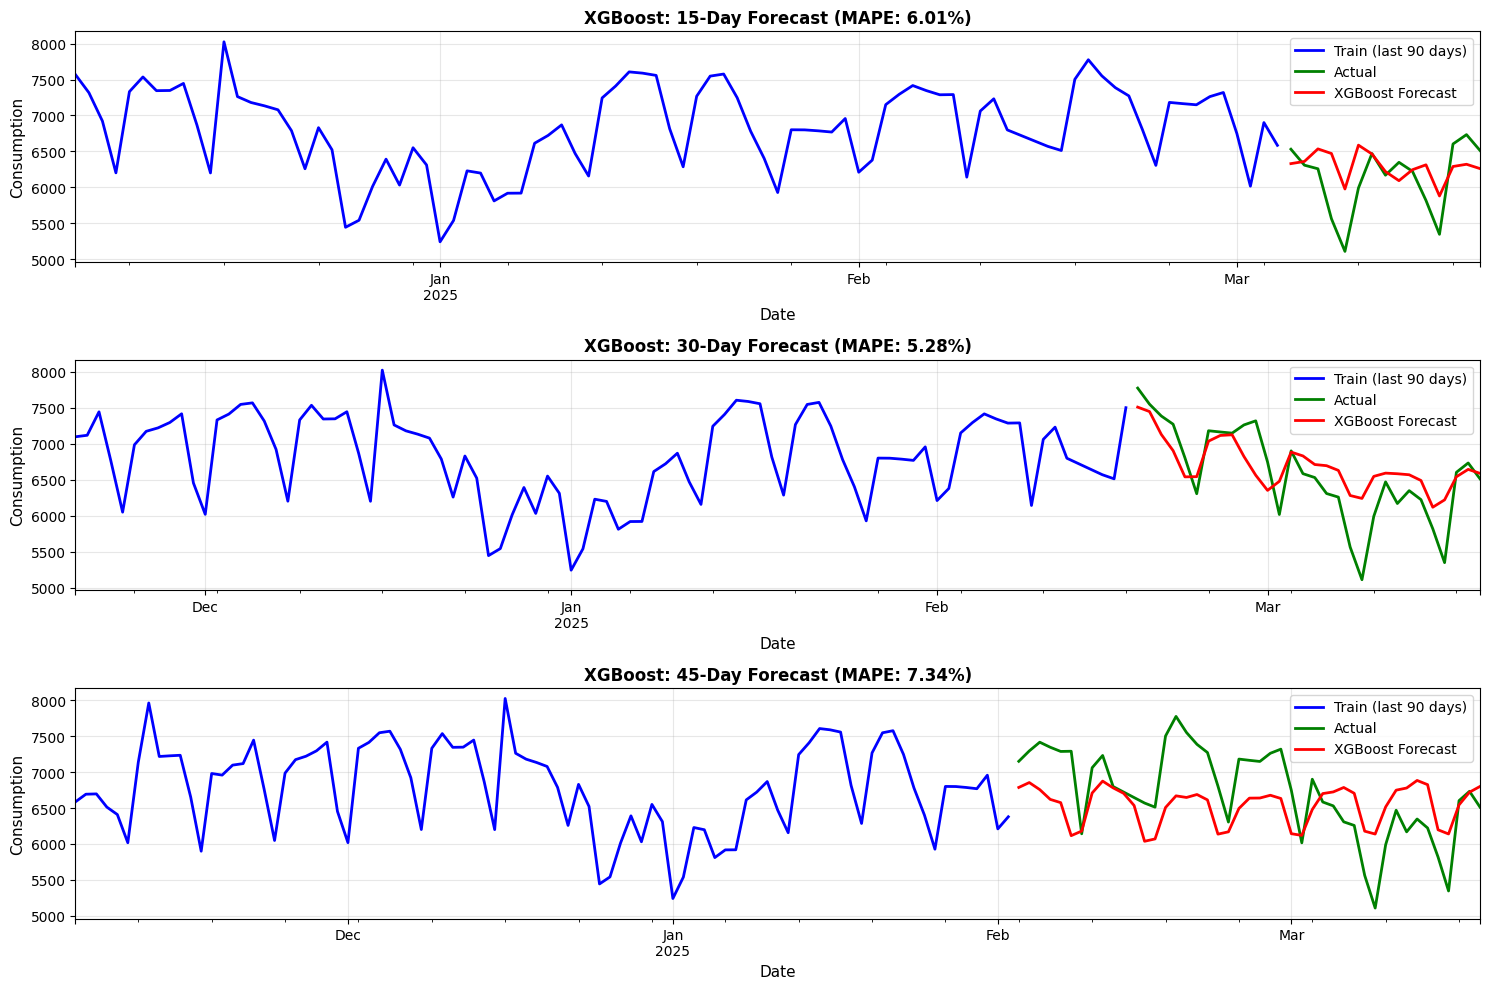

In [48]:
plot_forecasts(steps, xgb_forecasts, 'XGBoost')

# Amazon Chronos2 (Zero-Shot Pretrained Transformer) 

In [49]:
from darts.models import Chronos2Model

chron_forecasts = {}

for step, (train, test) in steps.items():
    print(f"Training Chronos for {step}-day forecast")
    
    model = Chronos2Model(
        model_name='amazon/chronos-t5-base',
        input_chunk_length=30,
        output_chunk_length=step
    )
    
    model.fit(train)
    
    forecast = model.predict(step)
    chron_forecasts[step] = forecast

print("\nTraining of all Chronos models completed successfully")

Training Chronos for 15-day forecast


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 15.25it/s]
Training Chronos for 30-day forecast


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 17.43it/s]
Training Chronos for 45-day forecast


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 13.48it/s]

Training of all Chronos models completed successfully


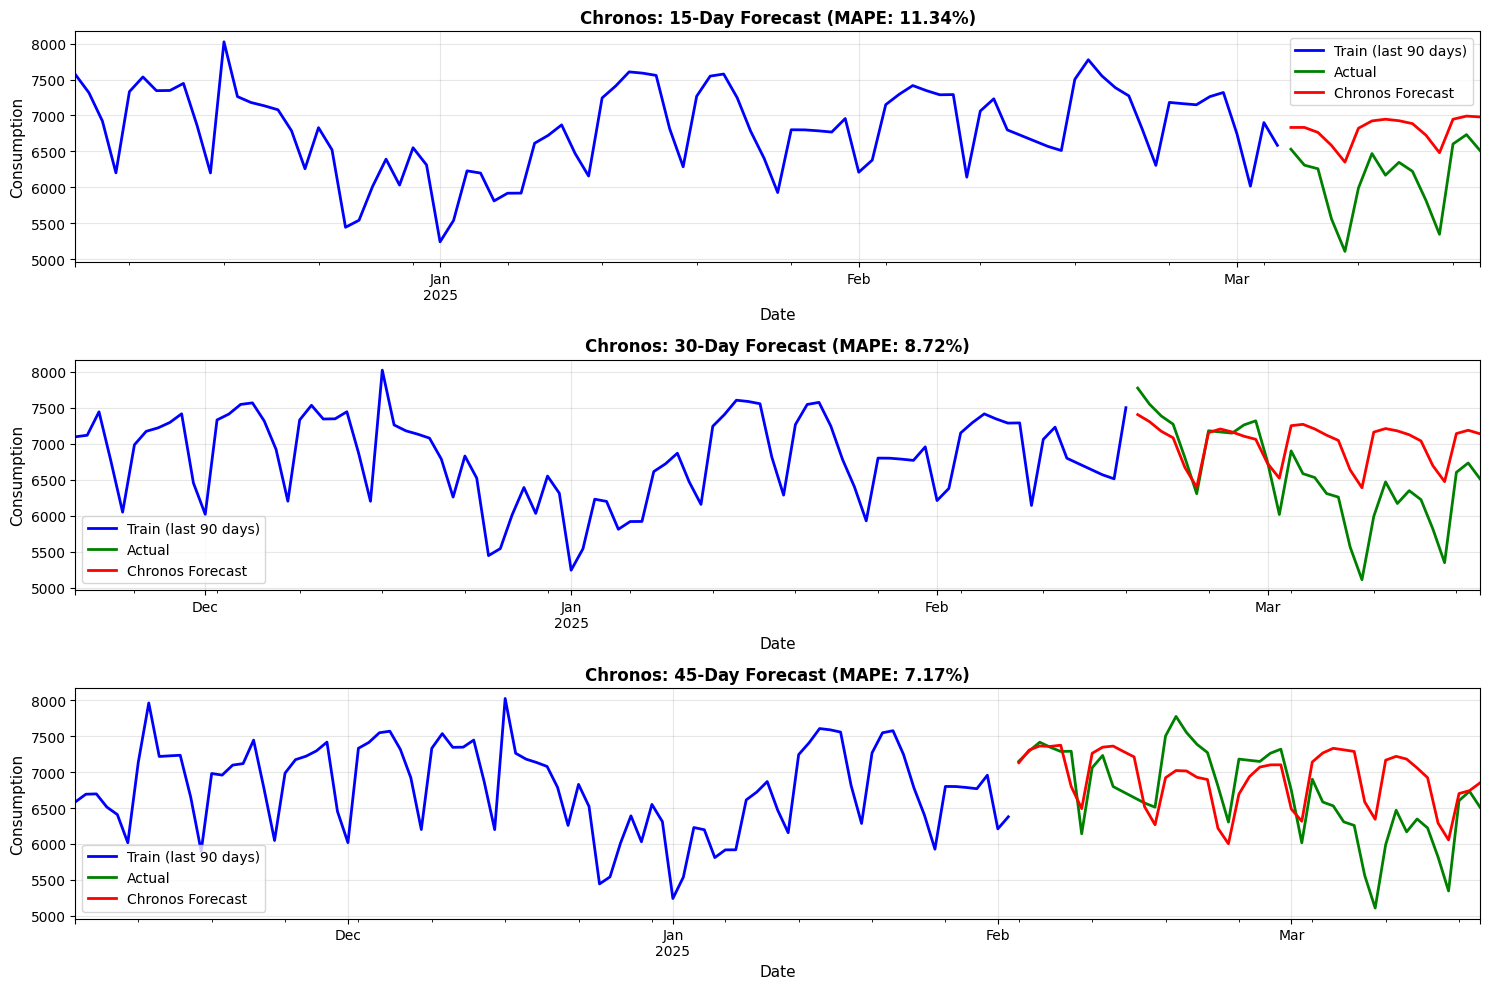

In [50]:
plot_forecasts(steps, chron_forecasts, 'Chronos')

# Model Comparison

Comparison of all models' accuracy by MAPE metric across different forecast horizons.

MODELS COMPARISON

  Model  Forecast Days  MAPE (%)
 SARIMA             15      3.67
     ES             15      4.73
Prophet             15      7.59
XGBoost             15      6.01
Chronos             15     11.34
 SARIMA             30      3.82
     ES             30     15.20
Prophet             30      5.60
XGBoost             30      5.28
Chronos             30      8.72
 SARIMA             45      5.65
     ES             45      9.91
Prophet             45      5.41
XGBoost             45      7.34
Chronos             45      7.17

MAPE PIVOT TABLE

Forecast Days     15     30    45
Model                            
Chronos        11.34   8.72  7.17
ES              4.73  15.20  9.91
Prophet         7.59   5.60  5.41
SARIMA          3.67   3.82  5.65
XGBoost         6.01   5.28  7.34


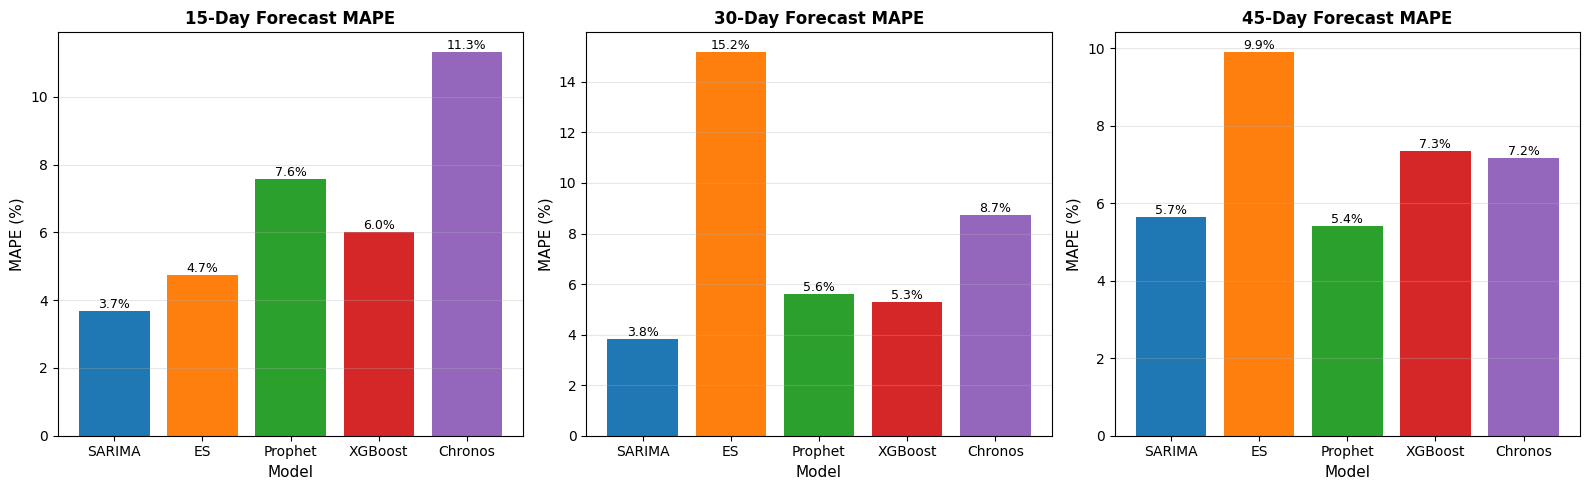


 BEST MODEL FOR EACH HORIZON 

15 days: SARIMA (MAPE: 3.67%)
30 days: SARIMA (MAPE: 3.82%)
45 days: Prophet (MAPE: 5.41%)


In [51]:
models_data = []

for step in [15, 30, 45]:
    for model_name, forecasts_dict in [
        ('SARIMA', sarima_forecasts),
        ('ES', es_forecasts),
        ('Prophet', prophet_forecasts),
        ('XGBoost', xgb_forecasts),
        ('Chronos', chron_forecasts)
    ]:
        forecast = forecasts_dict[step]
        test = steps[step][1]
        mape = evaluate_forecast(test, forecast)
        models_data.append({
            'Model': model_name,
            'Forecast Days': step,
            'MAPE (%)': mape
        })

comparison_df = pd.DataFrame(models_data)

print("MODELS COMPARISON\n")
print(comparison_df.to_string(index=False))

pivot_df = comparison_df.pivot(index='Model', columns='Forecast Days', values='MAPE (%)')
print("\nMAPE PIVOT TABLE\n")
print(pivot_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, step in enumerate([15, 30, 45]):
    ax = axes[idx]
    data = comparison_df[comparison_df['Forecast Days'] == step]
    
    bars = ax.bar(data['Model'], data['MAPE (%)'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    ax.set_title(f'{step}-Day Forecast MAPE', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAPE (%)', fontsize=11)
    ax.set_xlabel('Model', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n BEST MODEL FOR EACH HORIZON \n")
for step in [15, 30, 45]:
    best = comparison_df[comparison_df['Forecast Days'] == step].loc[comparison_df[comparison_df['Forecast Days'] == step]['MAPE (%)'].idxmin()]
    print(f"{step} days: {best['Model']} (MAPE: {best['MAPE (%)']:.2f}%)")